In [1]:
import sys
import os

# Lấy thư mục hiện tại (notebooks)
cwd = os.getcwd()

# Đi lên cho tới khi thấy thư mục "src"
project_root = cwd
while not os.path.isdir(os.path.join(project_root, "src")):
    project_root = os.path.dirname(project_root)

# Thêm src vào sys.path
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("✅ Project root:", project_root)
print("✅ Src path added:", src_path)


✅ Project root: d:\shopping_cart_analysis
✅ Src path added: d:\shopping_cart_analysis\src


In [2]:
from apriori_library import AssociationRulesMiner, DataVisualizer
print("✅ Import apriori_library thành công")


✅ Import apriori_library thành công


In [3]:
import pandas as pd

basket_path = os.path.join(
    project_root,
    "data",
    "processed",
    "basket_bool.parquet"
)

print("📦 Loading basket from:", basket_path)

basket_bool = pd.read_parquet(basket_path)
print("✅ Basket shape:", basket_bool.shape)


📦 Loading basket from: d:\shopping_cart_analysis\data\processed\basket_bool.parquet
✅ Basket shape: (18021, 4007)


In [4]:
rules_path = os.path.join(
    project_root,
    "data",
    "processed",
    "rules_apriori_filtered.csv"
)

rules_df = pd.read_csv(rules_path)
print("✅ Rules loaded:", rules_df.shape)
rules_df.head()


✅ Rules loaded: (1794, 17)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str,consequents_str,rule_str
0,"frozenset({'HERB MARKER PARSLEY', 'HERB MARKER...",frozenset({'HERB MARKER THYME'}),0.011487,0.012763,0.010932,0.951691,74.567045,1.0,0.010785,20.435808,0.998053,0.820833,0.951066,0.904106,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY",HERB MARKER THYME,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY → HE..."
1,"frozenset({'HERB MARKER MINT', 'HERB MARKER TH...",frozenset({'HERB MARKER ROSEMARY'}),0.011098,0.012818,0.010599,0.955000,74.502403,1.0,0.010456,21.937369,0.997650,0.795833,0.954416,0.890920,"HERB MARKER MINT, HERB MARKER THYME",HERB MARKER ROSEMARY,"HERB MARKER MINT, HERB MARKER THYME → HERB MAR..."
2,"frozenset({'HERB MARKER MINT', 'HERB MARKER TH...",frozenset({'HERB MARKER PARSLEY'}),0.011098,0.012652,0.010432,0.940000,74.297105,1.0,0.010292,16.455802,0.997612,0.783333,0.939231,0.882281,"HERB MARKER MINT, HERB MARKER THYME",HERB MARKER PARSLEY,"HERB MARKER MINT, HERB MARKER THYME → HERB MAR..."
3,"frozenset({'HERB MARKER PARSLEY', 'HERB MARKER...",frozenset({'HERB MARKER ROSEMARY'}),0.011487,0.012818,0.010932,0.951691,74.244244,1.0,0.010784,20.434660,0.997995,0.817427,0.951064,0.902252,"HERB MARKER PARSLEY, HERB MARKER THYME",HERB MARKER ROSEMARY,"HERB MARKER PARSLEY, HERB MARKER THYME → HERB ..."
4,"frozenset({'HERB MARKER BASIL', 'HERB MARKER T...",frozenset({'HERB MARKER ROSEMARY'}),0.011265,0.012818,0.010710,0.950739,74.169983,1.0,0.010565,20.039787,0.997757,0.800830,0.950099,0.893118,"HERB MARKER BASIL, HERB MARKER THYME",HERB MARKER ROSEMARY,"HERB MARKER BASIL, HERB MARKER THYME → HERB MA..."


In [17]:
supports = [0.01, 0.02, 0.03]
rule_counts = []

# Khởi tạo miner
miner = AssociationRulesMiner(basket_bool)

for s in supports:
    # 1️⃣ BƯỚC 1: Tìm tập phổ biến (Sửa .fit thành .mine_frequent_itemsets)
    miner.mine_frequent_itemsets(min_support=s) 
    
    # 2️⃣ BƯỚC 2: Sinh luật sơ bộ (Dùng Lift làm chuẩn ban đầu)
    miner.generate_rules(metric="lift", min_threshold=1.2)
    
    # 3️⃣ BƯỚC 3: Lọc luật (Dùng hàm filter_rules của thư viện để lọc Confidence)
    # Hàm generate_rules ở trên không hỗ trợ lọc confidence trực tiếp
    rules_filtered = miner.filter_rules(
        min_confidence=0.3,  # Lọc confidence tại đây
        min_lift=1.2         # Lọc lift tại đây (cho chắc chắn)
    )
    
    # Lưu số lượng luật
    rule_counts.append(len(rules_filtered))
    print(f"Support {s}: Tìm thấy {len(rules_filtered)} luật")

# Hiển thị kết quả để vẽ biểu đồ
print("Kết quả rule_counts:", rule_counts)

Support 0.01: Tìm thấy 2374 luật
Support 0.02: Tìm thấy 184 luật
Support 0.03: Tìm thấy 21 luật
Kết quả rule_counts: [2374, 184, 21]


Đang đọc file basket_bool.parquet...
Đã tải dữ liệu thành công! Kích thước: (18021, 4007)
Đang chạy Apriori...
Đang sinh luật kết hợp...
Đang vẽ Hình 1: Mạng lưới sản phẩm (Phát hiện cụm HERB MARKER)...


c:\Users\Mr Vinh\.conda\envs\dataminingnew\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\Mr Vinh\.conda\envs\dataminingnew\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\Mr Vinh\.conda\envs\dataminingnew\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


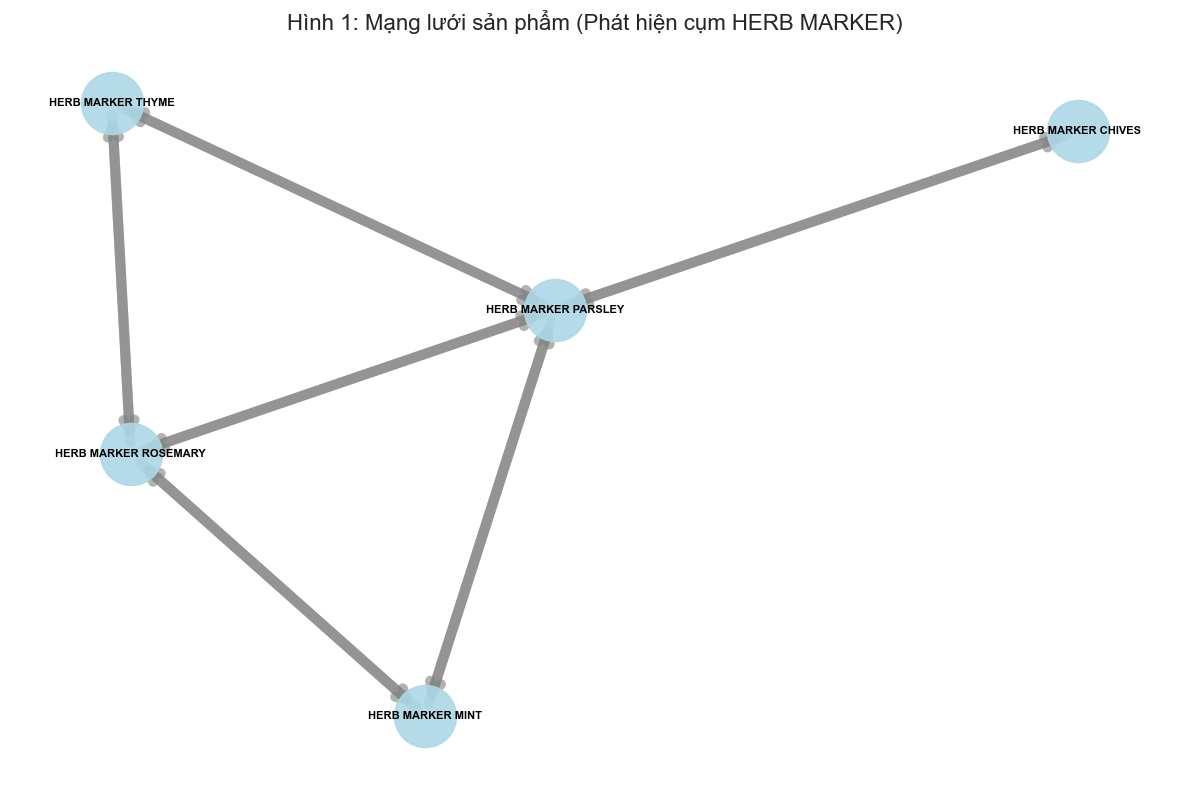

Đang vẽ Hình 2: Top các luật có Lift cao nhất...


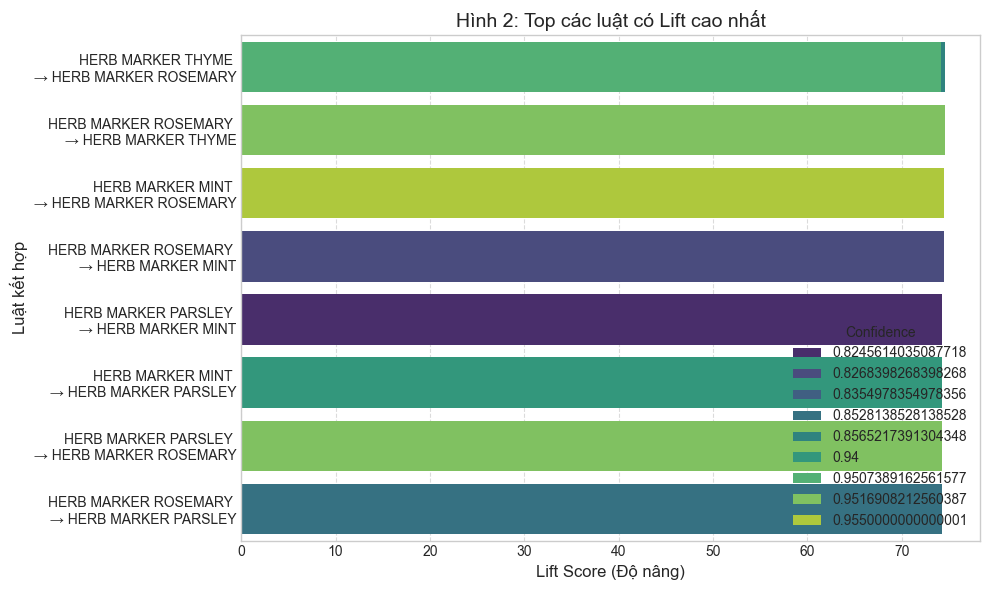

In [24]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

# Cấu hình giao diện
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# ---------------------------------------------------------
# 1. ĐỌC DỮ LIỆU TỪ FILE PARQUET CỦA BẠN
# ---------------------------------------------------------
try:
    print("Đang đọc file basket_bool.parquet...")
    # Thêm r ở đầu để Python hiểu đây là chuỗi thô, không dịch ký tự đặc biệt
    # Thêm ../ để lùi ra khỏi thư mục 'notebooks'
    basket_bool = pd.read_parquet('../data/processed/basket_bool.parquet')
    print(f"Đã tải dữ liệu thành công! Kích thước: {basket_bool.shape}")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")
    # Dừng chương trình nếu không đọc được file
    raise

# ---------------------------------------------------------
# 2. CHẠY THUẬT TOÁN APRIORI (Kịch bản A: Support thấp)
# ---------------------------------------------------------
print("Đang chạy Apriori...")
# min_support = 0.01 để bắt được các nhóm hàng ngách như Herb Marker
frequent_itemsets = apriori(basket_bool, min_support=0.01, use_colnames=True)

print("Đang sinh luật kết hợp...")
# min_lift = 1.2 để lọc các luật có ý nghĩa
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Tạo cột tên luật để vẽ biểu đồ
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['consequents_str'] = rules['consequents'].apply(lambda x: list(x)[0])
rules['rule_name'] = rules['antecedents_str'] + " \n→ " + rules['consequents_str']

# ---------------------------------------------------------
# 3. VẼ BIỂU ĐỒ 1: NETWORK GRAPH
# ---------------------------------------------------------
def plot_network_graph(rules_df, title="Mạng lưới sản phẩm"):
    print(f"Đang vẽ {title}...")
    G = nx.DiGraph()
    
    # Chỉ lấy Top 20 luật có Lift cao nhất để vẽ cho đỡ rối
    top_rules = rules_df.sort_values('lift', ascending=False).head(20)
    
    for _, row in top_rules.iterrows():
        G.add_edge(row['antecedents_str'], row['consequents_str'], weight=row['lift'])
    
    plt.figure(figsize=(12, 8))
    # Spring layout giúp các cụm liên kết mạnh (như Herb Marker) tự động gom lại gần nhau
    pos = nx.spring_layout(G, k=1.5, seed=42)
    
    # Độ dày mũi tên tỷ lệ với Lift
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    width = [w / 10 for w in weights] # Scale nhỏ lại để vẽ
    
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=width, edge_color='gray', 
                           arrowstyle='->', arrowsize=20, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_network_graph(rules, title="Hình 1: Mạng lưới sản phẩm (Phát hiện cụm HERB MARKER)")

# ---------------------------------------------------------
# 4. VẼ BIỂU ĐỒ 2: TOP LIFT RULES
# ---------------------------------------------------------
def plot_top_lift_rules(rules_df, title="Top Rules by Lift"):
    print(f"Đang vẽ {title}...")
    plt.figure(figsize=(10, 6))
    
    # Lấy Top 10 luật
    top_lift_rules = rules_df.sort_values('lift', ascending=False).head(10)
    
    sns.barplot(data=top_lift_rules, x='lift', y='rule_name', 
                hue='confidence', palette='viridis', dodge=False)
    
    plt.title(title, fontsize=14)
    plt.xlabel("Lift Score (Độ nâng)", fontsize=12)
    plt.ylabel("Luật kết hợp", fontsize=12)
    plt.legend(title='Confidence', loc='lower right')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_top_lift_rules(rules, title="Hình 2: Top các luật có Lift cao nhất")